# Lab Assignment: Generative AI

#### Lab team: teamCode

##### Name (member 1): firstName_1 lastName1_1 lastName1_2

##### Name (member 2): firstName_2 lastName2_1 lastName2_2

* Please include your full name at the beginning of all submitted files.
* Make sure the presentation is well-structured: the report will be evaluated not only for correctness, but also for clarity, conciseness, and completeness.
* Make use of figures and tables to summarize the results and illustrate the discussions.
* If external material is used, the sources must be cited. 
* Include references in APA format https://pitt.libguides.com/citationhelp/apa7. Lack or poorly formatted references can be penalized.
* A generative AI tool can be used for consultation. You must specify the tool used in your report.
* You are not allowed to use a generative AI tool to generate code.

Submit a single `.zip` file, whose name has the format `AA3_2024_2025_P02_teamCode_lastName1_lastName2.zip` 
The name must not include graphical accents, spaces, uppercase letters, or special characters.

For example: `AA3_2024_2025_P02_V03_munyoz_deLaRosa.zip`

This compressed file must include the following files:

* This Python notebook with the solutions of the exercises. The notebook should include only code snippets, figures, tables, derviations and explanations (with LaTex if necessary) in Markdown cells. Handwritten material can be included in the Python notebook as images. Functions should be defined in a separate `.py` file, not in the notebook.
* The necessary `.py` and addional files to ensure the Python notebook code can be executed sequentially without errors.
* A PDF file generated from the notebook (Export the notebook as an HTML file. Open the HTML file in a Browser and print it as a PDF file). 

Make sure that all the code cells can be executed squentially without errors (Kernel -> Restart & Run All). Exectution and formatting errors will be penalized.

The grade of this lab assignment is based on
* This submission (50 %).
* An individual in-class exam (50%).


Evaluation criteria:
* [6 points] Quality of the report (correctness, clarity, conciseness, completeness).
* [3 points] Quality of the code (correctness, adherence to a Python style guide -for instance, Google's-, comments, functional decomposition).
* [1 point]  References.                                                                   

## References:

1. Yang Song, Jascha Sohl-Dickstein, Diederik P. Kingma, Abhishek Kumar, Stefano Ermon and Ben Poole
"Score-Based Generative Modeling through Stochastic Differential Equations"
In International Conference on Learning Representations, 2021
https://arxiv.org/abs/2011.13456
2. H. Pan, Q. Zhou and L. J. Latecki, "SGUNET: Semantic Guided UNET For Thyroid Nodule Segmentation,"
2021 IEEE 18th International Symposium on Biomedical Imaging (ISBI), Nice, France, 2021, pp. 630-634 
https://ieeexplore.ieee.org/document/9434051
3. P. Vincent, â€œA connection between score matching and denoising autoencoders,â€
Tech. Rep. 1358, Department of Computer Science and Operations Research, Uni-
versity of Montreal, 2010.
4. A. HyvÂ¨arinen, â€œEstimation of non-normalized statistical models by score matching,â€
Journal of Machine Learning Research, vol. 6, no. 24, pp. 695â€“709, 2005.

## Exercise 1:  Generative AI based on diffusion models: Brownian motion 

In this exercise the training data is generated by injectiong noise using Brownian motion (variance exploding diffusion model).
The stochastic differencial equation (SDE) that characterizes this forward diffusion process is
$$
d\mathbf{x}(t) = \sigma^t d\mathbf{W}(t) 
$$

with $ \mathbf{x}(0) \sim p_0\left(\mathbf{x} \right)$, and  $\sigma > 0 $.
1. What is the distribution of $\mathbf{x}(t)$ assuming that $\mathbf{x}(0) = \mathbf{x}_0$ for arbitrary t?
  
   Since there is no drift term we only need to integrate the diffusion by the general formal solution of an SDE with ItÃ´'s form given the initial condition.
   $$
   \mathbf{x}(t) = \mathbf{x}_0 + \int_0^t \sigma^{s} dW(s)
   $$

   We know the ItÃ´'s solution follows a gaussian with $\mu = \mathbf{x}_0 $ but we need to calculate $\sigma^2(t)$ which in our case is:
$$
\sigma^2(t) = \int_0^t g^2(s)ds = \int_0^t \sigma^{2s} ds = \frac{\sigma^{2t} - 1}{2log\sigma}
$$

Finally we get: $$\mathbf{x}(t) \sim \mathcal{N}\!\left(\mathbf{x}_0,\ \frac{\sigma^{2t}-1}{2\ln\sigma}\,\mathbf{I}\right)$$

Note: An alternative approach is given by Song (2021) as referenced in our memory and is such as:

$$ \sigma^2(t) = \sigma_{\text{min}}(\frac{\sigma_{\text{max}}}{\sigma_{\text{min}}})^t \approx \sigma^{2t}$$

In this case we determine $\sigma$ by an heuristic manner that depends on the dataset

1. What is the SDE for the time-reversed process? 
   $$d\textbf{x} = -\sigma^{2t}\nabla_\textbf{x}\operatorname{log}p_t(\textbf{x})dt + \sigma^t dW$$
2. For the synthesis of new images
    1. In what interval is the reverse process SDE integrated?
    
    We need to integrate from the furthest moment of the forward process, in this case $t=T$ until the original moment $t=0$
    $$
    t \in [T, 0]
    $$
    2. From which distribution $\pi\left(\mathbf{x} \right)$ is the initial condition of the reverse SDE sampled?
    
    Note that we are in the reversed process so $x(T) = x_T$ and this is sampled from this distribution:

$$\mathbf{x}(T) \sim \mathcal{N}\!\left(\mathbf{0},\ \frac{\sigma^{2T}-1}{2\ln\sigma}\,\mathbf{I}\right)$$

### Exercise 1.1:  Training the model by weighted sum of denoising score matching objectives
1. Give the mathematical form and explain the cost function used in the training of the generative AI model.
$$ \ell(\boldsymbol{\theta}) = \frac{1}{N} \sum_{n=1}^N \left\| \sigma(t_n) \, s_{\theta}(\mathbf{x}(t_n), t_n) + \mathbf{z}_n\right\|_2^2
$$
This function is an evolution of the cost function stated by Aapo HyvÃ¤rine (2005) and further conclusions from Vincent (2011),  rewritten by Yang Song (2021) focused on noise detection. (note here we use loss/cost function indistinguishably). 

What this fucntion means intuintively is that our $ s_{\theta}(\mathbf{x}(t_n), t_n)$ in practice implemented as  U-net is going to try to predict the noise that we have previously injected at each corruption step. We achieve this because we know that $\nabla_{\mathbf{x}} \log p_{0t}\!\left(\mathbf{x}(t_n)\mid\mathbf{x}_0\right) = -\frac{\mathbf{z}_n}{\sigma(t_n)}$ and our prediction is $s_{\theta}(\mathbf{x}(t_n), t_n) \approx \nabla_{\mathbf{x}} \log p_t(\mathbf{x}(t_n))$ so we are essentially calculating with the norm $L_2$ the distance between the predicted score  $s_{\theta}$ â€‹and the true score $-\frac{\mathbf{z}_n}{\sigma(t_n)}$, which is known during training because we injected $\mathbf{z}_n$
ourselves.

2. Indicate what type of neural network is used to model the score, its inputs, outputs, and architecture.   

To model the score we use a **U-net** (Pan et al. (2021) and lecture notes)

**Inputs**:
- The image we have introduced noise to in our case $\mathbf{x}(t) \in \mathbb{R}^{64 \times 64 \times C}$ at corruption level $t$
- Time "t"

**Output**:
- The estimated score $s_{\theta}(\mathbf{x}(t), t) \in \mathbb{R}^{64 \times 64 \times C}$, 

**Architecture**:
- **Encoder**:Downsamples the resolution by convolutional blocks and max-pooling, incrementing the depth of the channels at each level
- **Decoder**: Recovers the original resolution by transposed convolutions
- **Skip-connections**: Connects the charateristic maps of each level of the encoder to the decoder

3. Explain how time is input in the neural network model for the time-dependent score function using random Fourier features.
   Time is input by random Fourier feature embeddings
4. Illustrate how to train a model to generate handwritten digits for the MNIST dataset using the Brownian motion diffusion model.
This first block of code should run in less than 5 minutes.

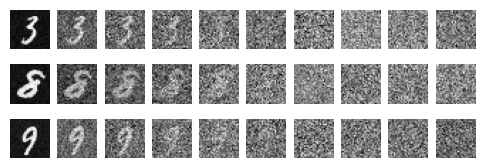

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from diffusion_lib import VEProcess
from diffusion_utilities import plot_image_evolution

# 1. Cargar unas imÃ¡genes MNIST limpias
dataset = datasets.MNIST(root='data', train=True, download=True,
                         transform=transforms.ToTensor())
loader  = DataLoader(dataset, batch_size=64, shuffle=True)
x_0, _  = next(iter(loader))        # [B, 1, 28, 28]
n_images = 3
x_0 = x_0[:n_images]

# 2. El mismo proceso forward que usaste al entrenar
ve = VEProcess(sigma=25.0)

# 3. Elegir tiempos. Para VE con sigma=25 conviene espaciado log-ish,
#    porque la varianza crece exponencialmente con t.
times = torch.tensor([1e-3, 0.05, 0.10, 0.20, 0.30,
                      0.50, 0.70, 0.85, 0.95, 1.00])

# 4. Aplicar el kernel cerrado p(x_t | x_0) a cada t y apilar en el formato
#    que pide plot_image_evolution: (n_images, C, H, W, n_steps)
trajectory = []
for t in times:
    t_batch = t.expand(n_images)
    x_t, _  = ve.perturb(x_0, t_batch)     # (n_images, 1, 28, 28)
    trajectory.append(x_t)
images_t = torch.stack(trajectory, dim=-1)  # (n_images, 1, 28, 28, len(times))

# 5. Mismo plot que en el demo
_ = plot_image_evolution(
    images=images_t,
    n_images=n_images,
    n_intermediate_steps=list(range(len(times))),  # los 10 a la vez
    figsize=(6, 2),
)

### Exercise 1.2: Generation using the Euler-Maruyama integrator
Use a model that you have previously trained (not the one in the previous exercise) high-quality model to generate some samples using the Euler-Maruyama integrator.

In [ ]:
import torch
from score_model_digits_color import ScoreNet as ScoreNetColor
from diffusion_lib import VEProcess, EulerMaruyamaSampler, GenerativeDiffusionModel

device = torch.device('cpu')


ve_process = VEProcess(sigma=25.0)
score_model = ScoreNetColor(marginal_prob_std=ve_process.sigma_t)

n_epochs = 500
checkpoint = torch.load(
    f'digit_6_{n_epochs}_epochs.pth',
    map_location=device,
    weights_only=True,
)
score_model.load_state_dict(checkpoint)

gm = GenerativeDiffusionModel(ve_process, EulerMaruyamaSampler(), score_model, device)

n_images = 5
synthetic_images_t = gm.sample(
    n_images=n_images,
    img_shape=(3, 32, 32),
    n_steps=500,
    return_trajectory=True,
)

print(f"Dimensiones finales: {synthetic_images_t.shape}")

Dimensiones finales: torch.Size([5, 3, 32, 32, 501])


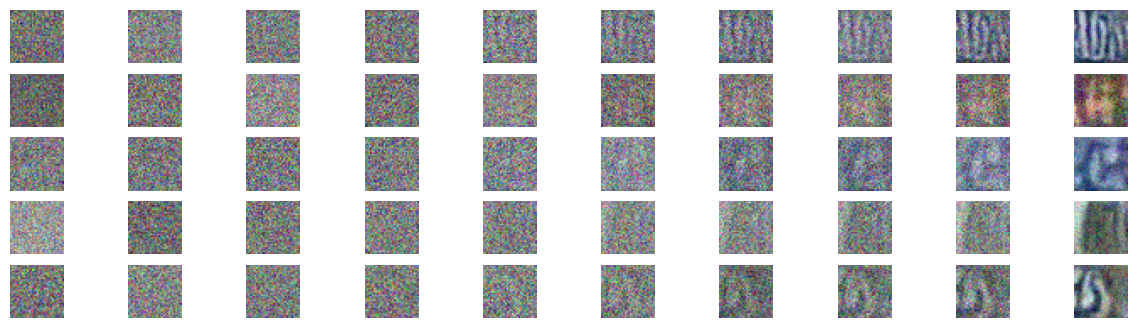

In [3]:
from diffusion_utilities import plot_image_evolution_rgb

_ = plot_image_evolution_rgb(
    
    images=synthetic_images_t,
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

### Exercise 1.3: Generation using a probability flow ODE.
1. Explain what is the Fokker-Planck equation and in what way is it related to an SDE.
$$    
    dX_t = \left[
        -\frac{\beta(t)}{2}\,X_t
        - \beta(t)\,\nabla_{x}\log p_t(X_t)
    \right]dt
    + \sqrt{\beta(t)}\,d\bar{W}_t
$$

1. Explain how the probability flow ODE can be used to generate samples from  $p_0\left(\mathbf{x} \right)$.
2. Implement and illustrate the use of this method to generate synthetic images of handwritten digits. 
3. Indicate how to use this scheme to compute likelihoods. Implement this functionality and illustrate its use.

In [ ]:
import torch
from score_model_digits_color import ScoreNet as ScoreNetColor
from diffusion_lib import VEProcess, ProbabilityFlowODESampler, GenerativeDiffusionModel

device = torch.device('cpu')

ve_process = VEProcess(sigma=25.0)
score_model = ScoreNetColor(marginal_prob_std=ve_process.sigma_t)

checkpoint = torch.load(
    'digit_6_500_epochs.pth',
    map_location=device,
    weights_only=True,
)
score_model.load_state_dict(checkpoint)
print("Modelo cargado.")


gm_ode = GenerativeDiffusionModel(ve_process, ProbabilityFlowODESampler(), score_model, device)

n_images = 5
trajectory = gm_ode.sample(
    n_images=n_images,
    img_shape=(3, 32, 32),
    n_steps=500,
    return_trajectory=True,
)

print(f"Trayectoria ODE: {trajectory.shape}")

Modelo cargado.
Trayectoria ODE: torch.Size([5, 3, 32, 32, 501])


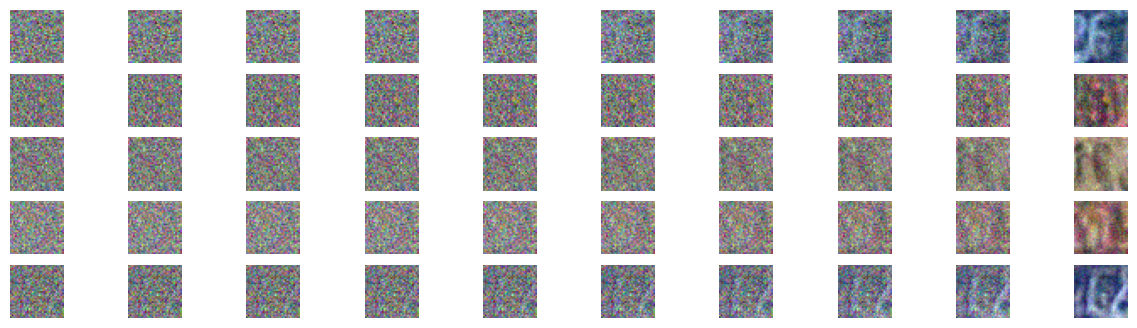

In [5]:
from diffusion_utilities import plot_image_evolution_rgb

_ = plot_image_evolution_rgb(
    images=trajectory,
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

## Exercise 2:  Generative AI based on diffusion models: The Ornstein-Uhlenbeck process

In this exercise, the training data is generated by injecting noise using Brownian motion (variance preserving diffusion model).
The stochastic differencial equation (SDE) that characterizes this forward diffusion process is
$$
d\mathbf{x}(t) = - \frac{1}{2} \beta(t) \mathbf{x}(t) + \sqrt{\beta(t)} d\mathbf{W}(t) 
$$

with $ \mathbf{x}(0) \sim p_0\left(\mathbf{x} \right)$
1. What is the distribution of $\mathbf{x}(t)$ assuming that $\mathbf{x}(0) = \mathbf{x}_0$ for arbitrary t?

We will unveil the distribution of $\mathbf{x}(t)$ using the solution to the Ornstein-Uhlbeck SDE:
$$
\mathbf{x}(t) = e^{-\frac{1}{2}\int_0^t \beta(s)\,ds}\,\mathbf{x}_0 + \int_0^t e^{-\frac{1}{2}\int_\tau^t \beta(s)\,ds} \sqrt{\beta(\tau)}\, d\mathbf{W}(\tau)
$$
$$
\mu(t) = e^{-\frac{1}{2}\int_0^t \beta(s)\,ds}\,\mathbf{x}_0     \xrightarrow{t \to \infty} \mathbf{0}
$$
$$
\sigma^2(t) = e^{-\int_0^t \beta(s)\,ds} \int_0^t e^{\int_0^\tau \beta(s)\,ds}\,\beta(\tau)\,d\tau     \xrightarrow{t \to \infty} 1 
$$
Therefore, as $t \to \infty$:
 
$$
\mathbf{x}(t) \sim \mathcal{N}\!\left(\mathbf{0},\ \mathbf{I}\right)
$$
2. What is the SDE for the time-reversed process? 
 
$$
d\mathbf{x} = \left[-\frac{1}{2}\beta(t)\mathbf{x} - \beta(t)\,\nabla_{\mathbf{x}}\log p_t(\mathbf{x})\right]dt + \sqrt{\beta(t)}\,d\bar{\mathbf{W}}
$$
3. For the synthesis of new images
   1. In what interval is the reverse process SDE integrated?
        We need to integrate from the furthest moment of the forward process, in this case $t=T$ until the original moment $t=0$
        $$
        t \in [T, 0]
        $$
   2. From which distribution $\pi\left(\mathbf{x} \right)$ is the initial condition of the reverse SDE sampled? 
        
        Knowing that $\tilde{\mathbf{x}}(T) \sim \mathcal{N}\!\left(\mathbf{0},\, \sigma^2(T)\,\mathbf{I}\right)$ it's easy to see that $\pi\left(\mathbf{x} \right) \sim \mathcal{N}\!\left(\mathbf{0},\ \mathbf{I}\right)$

### Exercise 2.1: Training and generation of images using the OU process and different noise schedules
1. Using the linear noise schedule.


In [6]:
from diffusion_lib import VPProcess, LinearSchedule
from score_model import ScoreNet
import torch.optim as optim


vp_process = VPProcess(schedule=LinearSchedule())
score_model_vp_lin = ScoreNet(marginal_prob_std=vp_process.sigma_t).to(device)
gm_vp_lin = GenerativeDiffusionModel(vp_process, EulerMaruyamaSampler(), score_model_vp_lin, device)
optimizer = optim.Adam(score_model_vp_lin.parameters(), lr=1e-3)

transform = transforms.Compose([transforms.ToTensor()])
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
subset = torch.utils.data.Subset(dataset, range(2000))
train_loader = DataLoader(subset, batch_size=64, shuffle=True)

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 500
loss_history = []

score_model_vp_lin.train()

print(f"Entrenando en {device}...")

for epoch in range(epochs):
    epoch_loss = 0
    for images, _ in train_loader:
        loss = gm_vp_lin.compute_loss(images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

torch.save(score_model_vp_lin.state_dict(), 'mnist_vp_linear_trained.pth')

Entrenando en cuda...
Epoch 1/500 | Loss: 1212.7690
Epoch 2/500 | Loss: 299.4636
Epoch 3/500 | Loss: 175.9616
Epoch 4/500 | Loss: 138.5357
Epoch 5/500 | Loss: 111.4017
Epoch 6/500 | Loss: 105.3716
Epoch 7/500 | Loss: 89.4778
Epoch 8/500 | Loss: 83.3869
Epoch 9/500 | Loss: 81.2599
Epoch 10/500 | Loss: 73.6805
Epoch 11/500 | Loss: 69.6746
Epoch 12/500 | Loss: 68.3063
Epoch 13/500 | Loss: 60.1797


KeyboardInterrupt: 

In [8]:
checkpoint = torch.load(
    'mnist_vp_linear_trained.pth',
    map_location=device,
    weights_only=True,
)
score_model_vp_lin.load_state_dict(checkpoint)

n_images = 5
synthetic_images_vp_lin = gm_vp_lin.sample(
    n_images=n_images,
    img_shape=(1, 28, 28),   # ScoreNet (score_model.py) has no padding â†’ 28x28 only
    n_steps=500,
    return_trajectory=True,
)

print(f"Dimensiones finales: {synthetic_images_vp_lin.shape}")

Dimensiones finales: torch.Size([5, 1, 28, 28, 501])


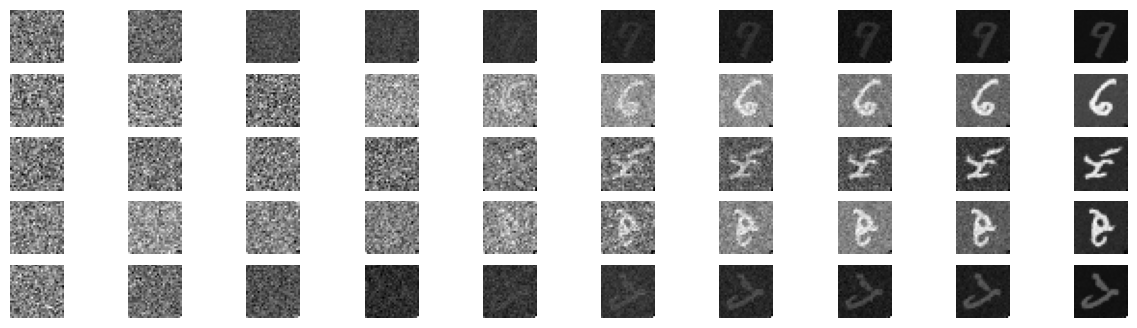

In [9]:
from diffusion_utilities import plot_image_evolution

_ = plot_image_evolution(
    images=synthetic_images_vp_lin.cpu(),
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

2. Using the cosine noise schedule.


In [10]:
from score_model import ScoreNet
from diffusion_lib import VPProcess, CosineSchedule, EulerMaruyamaSampler, GenerativeDiffusionModel
import torch.optim as optim

vp_process_cos = VPProcess(schedule=CosineSchedule())
score_model_vp_cos = ScoreNet(marginal_prob_std=vp_process_cos.sigma_t).to(device)
gm_vp_cos = GenerativeDiffusionModel(vp_process_cos, EulerMaruyamaSampler(), score_model_vp_cos, device)
optimizer = optim.Adam(score_model_vp_cos.parameters(), lr=1e-3)


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 500
loss_history = []

score_model_vp_cos.train()

print(f"Entrenando en {device}...")

for epoch in range(epochs):
    epoch_loss = 0
    for images, _ in train_loader:
        loss = gm_vp_cos.compute_loss(images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

torch.save(score_model_vp_cos.state_dict(), 'mnist_vp_cosine_trained.pth')

Entrenando en cuda...
Epoch 1/500 | Loss: 1280.1036
Epoch 2/500 | Loss: 416.4346
Epoch 3/500 | Loss: 295.3794
Epoch 4/500 | Loss: 232.2952
Epoch 5/500 | Loss: 181.0450


KeyboardInterrupt: 

In [11]:
checkpoint = torch.load(
    'mnist_vp_cosine_trained.pth',
    map_location=device,
    weights_only=True,
)
score_model_vp_cos.load_state_dict(checkpoint)
gm_vp_cos.T = 0.999   

n_images = 5
synthetic_images_vp_cos = gm_vp_cos.sample(
    n_images=n_images,
    img_shape=(1, 28, 28),   
    n_steps=500,
    return_trajectory=True,
)

print(f"Dimensiones finales: {synthetic_images_vp_cos.shape}")

Dimensiones finales: torch.Size([5, 1, 28, 28, 501])


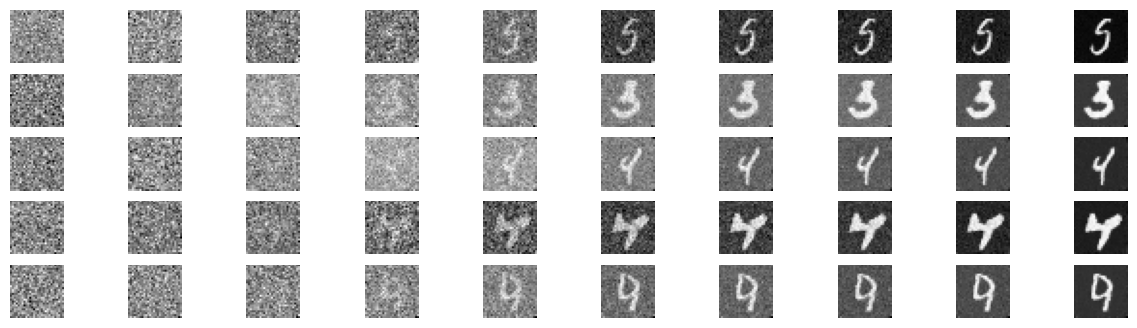

In [12]:
from diffusion_utilities import plot_image_evolution

_ = plot_image_evolution(
    images=synthetic_images_vp_cos.cpu(),
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

3. Using a third noise schedule of your choice.

In [16]:
from diffusion_lib import ExponentialSchedule
vp_process_exp= VPProcess(schedule=ExponentialSchedule())
score_model_vp_exp = ScoreNet(marginal_prob_std=vp_process_exp.sigma_t).to(device)
gm_vp_exp = GenerativeDiffusionModel(vp_process_exp, EulerMaruyamaSampler(), score_model_vp_exp, device)
optimizer = optim.Adam(score_model_vp_exp.parameters(), lr=1e-3)

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 500
loss_history = []

score_model_vp_exp.train()

print(f"Entrenando en {device}...")

for epoch in range(epochs):
    epoch_loss = 0
    for images, _ in train_loader:
        loss = gm_vp_exp.compute_loss(images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

torch.save(score_model_vp_exp.state_dict(), 'mnist_vp_exponential_trained.pth')

Entrenando en cuda...
Epoch 1/500 | Loss: 1311.6215
Epoch 2/500 | Loss: 399.3457
Epoch 3/500 | Loss: 283.2137
Epoch 4/500 | Loss: 221.0762
Epoch 5/500 | Loss: 193.8862
Epoch 6/500 | Loss: 172.1338
Epoch 7/500 | Loss: 159.6202
Epoch 8/500 | Loss: 139.7586
Epoch 9/500 | Loss: 132.6351
Epoch 10/500 | Loss: 126.9207
Epoch 11/500 | Loss: 117.0184
Epoch 12/500 | Loss: 112.6094
Epoch 13/500 | Loss: 109.6765
Epoch 14/500 | Loss: 105.1804
Epoch 15/500 | Loss: 101.6848
Epoch 16/500 | Loss: 97.4282
Epoch 17/500 | Loss: 92.9551
Epoch 18/500 | Loss: 92.2807
Epoch 19/500 | Loss: 94.4085
Epoch 20/500 | Loss: 88.2931
Epoch 21/500 | Loss: 91.6176
Epoch 22/500 | Loss: 88.1405
Epoch 23/500 | Loss: 86.3177
Epoch 24/500 | Loss: 82.1518
Epoch 25/500 | Loss: 78.1825
Epoch 26/500 | Loss: 76.3604
Epoch 27/500 | Loss: 78.2752
Epoch 28/500 | Loss: 76.8933
Epoch 29/500 | Loss: 76.9163
Epoch 30/500 | Loss: 74.5857
Epoch 31/500 | Loss: 76.9603
Epoch 32/500 | Loss: 74.5532
Epoch 33/500 | Loss: 73.7221
Epoch 34/500 |

In [23]:
checkpoint = torch.load(
    'mnist_vp_exponential_trained.pth',
    map_location=device,
    weights_only=True,
)
score_model_vp_exp.load_state_dict(checkpoint)

n_images = 5
synthetic_images_vp_exp = gm_vp_exp.sample(
    n_images=n_images,
    img_shape=(1, 28, 28),   
    n_steps=500,
    return_trajectory=True,
)

print(f"Dimensiones finales: {synthetic_images_vp_exp.shape}")

Dimensiones finales: torch.Size([5, 1, 28, 28, 501])


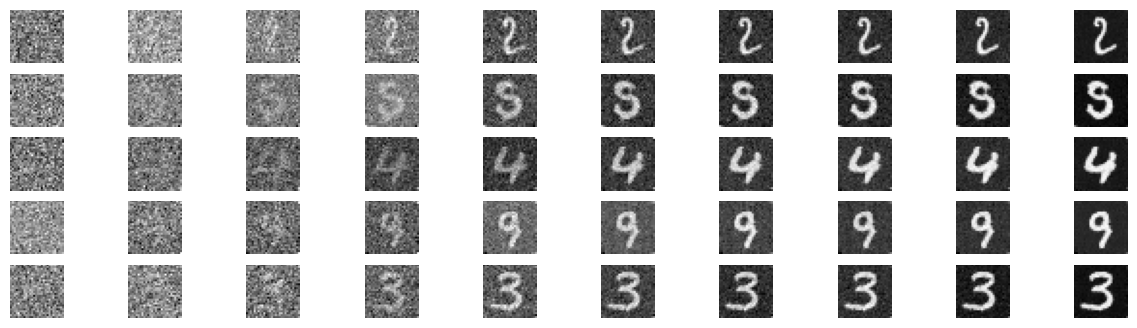

In [24]:
from diffusion_utilities import plot_image_evolution

_ = plot_image_evolution(
    images=synthetic_images_vp_exp.cpu(),
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

## Exercise 3:  Evaluation of the quality of the generated images
1. Describe, and compare the characteristics, advantages, and disadvantages of the following measures of quality for generative IA models for images:
    1. The negative log-likelihood (NLL).
    2. Bits per dimension (BPD). 
    3. Fréchet Inception Distance (FID).
    4. A third measure of your choice.
2. Compare using BPD the different diffusion models (Brownian motion, Ornstein-Uhlenbeck), noising schedules (linear, cosine, etc.), and sampling strategies (SDE, ODE) implemented.

VE  Brownian: -1.937 bpd
VP  Linear: -10.032 bpd
VP  Cosine: -10.574 bpd


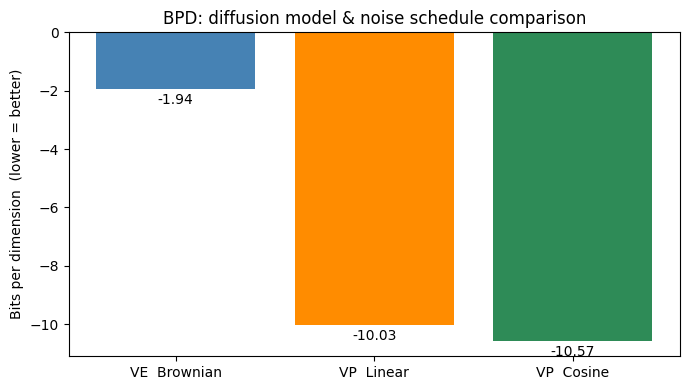

In [27]:
import torch
import matplotlib.pyplot as plt
from score_model import ScoreNet
from diffusion_lib import (
    VEProcess, VPProcess, LinearSchedule, CosineSchedule,
    EulerMaruyamaSampler, GenerativeDiffusionModel,
)
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Held-out test set — 32 images is enough for a fast BPD estimate
x_eval, _ = next(iter(
    DataLoader(
        datasets.MNIST(root='./data', train=False, download=True,
                       transform=transforms.ToTensor()),
        batch_size=32, shuffle=False,
    )
))

# One entry per model: (label, process, checkpoint)
configs = [
    ('VE  Brownian',  VEProcess(sigma=25.0),               'mnist_brownian_trained.pth'),
    ('VP  Linear',   VPProcess(schedule=LinearSchedule()), 'mnist_vp_linear_trained.pth'),
    ('VP  Cosine',   VPProcess(schedule=CosineSchedule()), 'mnist_vp_cosine_trained.pth'),
]

# BPD uses the probability-flow ODE internally (compute_bpd in GenerativeDiffusionModel),
# so results are independent of which sampler the model was trained / evaluated with.
bpd_vals, labels = [], []
for name, process, ckpt in configs:
    net = ScoreNet(marginal_prob_std=process.sigma_t)
    net.load_state_dict(torch.load(ckpt, map_location='cpu', weights_only=True))
    gm_eval = GenerativeDiffusionModel(process, EulerMaruyamaSampler(), net, device)
    bpd = gm_eval.compute_bpd(x_eval, n_steps=50, n_hutchinson=1).mean().item()
    bpd_vals.append(bpd)
    labels.append(name)
    print(f'{name}: {bpd:.3f} bpd')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, bpd_vals, color=['steelblue', 'darkorange', 'seagreen'])
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_ylabel('Bits per dimension  (lower = better)')
ax.set_title('BPD: diffusion model & noise schedule comparison')
plt.tight_layout()
plt.show()
